# Baseline CNN Model

##### Initial Setup

In [14]:
import sys
import time
import os
import json
import zipfile
from pathlib import Path

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping


from google.colab import drive

drive.mount("/content/drive")

DRIVE_PROJECT = Path("/content/drive/MyDrive/CSE475_Project")

DATASET_ZIP = DRIVE_PROJECT / "data" / "intel_dataset.zip"

COLAB_DATA_DIR = Path("/content/data")
COLAB_DATA_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = DRIVE_PROJECT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.baseline_cnn import build_baseline_cnn
from augmentation.augmentations import get_basic_augmentation, get_advanced_augmentation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### Dataset Setup

In [17]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15

DATASET_DIR = COLAB_DATA_DIR / "intel_dataset"

if not DATASET_DIR.exists():
    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall(COLAB_DATA_DIR)

print("Dataset path:", DATASET_DIR)

class_names = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


file_paths = []
labels = []

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

for label, class_name in enumerate(class_names):
    class_dir = DATASET_DIR / class_name

    for file_path in sorted(class_dir.iterdir()):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            file_paths.append(str(file_path))
            labels.append(label)

print("Total images:", len(file_paths))

Dataset path: /content/data/intel_dataset
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6
Total images: 16900


##### Train Test Split

In [18]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 11830
Validation images: 2535
Test images: 2535


##### Preprocessing

In [13]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

#### Experiment 1 | Baseline CNN with Basic Augmentation

##### Augmentation

In [19]:
data_augmentation = get_basic_augmentation()

##### Creating TensorFlow Datasets

In [20]:
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=SEED
        )

        ds = ds.map(
            lambda x, y: (
                data_augmentation(x, training=True),
                y
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(
    train_paths,
    train_labels,
    training=True
)

val_ds = make_dataset(
    val_paths,
    val_labels,
    training=False
)

test_ds = make_dataset(
    test_paths,
    test_labels,
    training=False
)

##### Setting Up the Model

In [7]:
baseline_model = build_baseline_cnn(
    num_classes=num_classes,
    input_shape=(*IMG_SIZE, 3)
)

baseline_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,988,550 (41.92 MB)

 Trainable params: 10,988,550 (41.92 MB)

 Non-trainable params: 0 (0.00 B)

##### Training the Model

In [8]:
start_time = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

end_time = time.time()

training_time = end_time - start_time

Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 101s 236ms/step - accuracy: 0.6110 - loss: 0.9939 - val_accuracy: 0.6714 - val_loss: 0.8824
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 85s 214ms/step - accuracy: 0.7146 - loss: 0.7594 - val_accuracy: 0.7400 - val_loss: 0.7330
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 85s 214ms/step - accuracy: 0.7516 - loss: 0.6589 - val_accuracy: 0.7452 - val_loss: 0.6950
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 84s 214ms/step - accuracy: 0.7773 - loss: 0.6052 - val_accuracy: 0.7874 - val_loss: 0.6121
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 84s 216ms/step - accuracy: 0.7976 - loss: 0.5493 - val_accuracy: 0.7925 - val_loss: 0.5783
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 142s 213ms/step - accuracy: 0.8085 - loss: 0.5105 - val_accuracy: 0.7980 - val_loss: 0.5518
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 87s 212ms/step - accuracy: 0.8231 - loss: 0.4828 - val_accuracy: 0.7913 - val_loss: 0.5713
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 85s 216ms/step - accuracy: 0.8291 - loss:

##### Evaluation

In [27]:
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(
    test_ds
)


y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

y_pred_probs = baseline_model.predict(
    test_ds
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)


baseline_waf1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)


baseline_cm = confusion_matrix(
    y_true,
    y_pred
)


y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

baseline_roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class="ovr",
    average="weighted"
)


print("Test Loss:", baseline_test_loss)
print("Test Accuracy:", baseline_test_acc)
print("Weighted F1 Score:", baseline_waf1)
print("Weighted ROC-AUC:", baseline_roc_auc)
print("Training Time (seconds):", round(training_time, 2))


FIGURE_DIR = DRIVE_PROJECT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN + Basic Augmentation — Confusion Matrix")

plt.savefig(
    FIGURE_DIR / "baseline_cnn_basic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_probs[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN + Basic Augmentation — ROC-AUC")
plt.legend()

plt.savefig(
    FIGURE_DIR / "baseline_cnn_basic_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'baseline_model' is not defined

##### Saving the Trained Model

In [10]:
MODEL_DIR = DRIVE_PROJECT / "saved_models" / "cnn_basic"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "baseline_cnn_basic.keras"
baseline_model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/CSE475_Project/saved_models/cnn_basic/baseline_cnn_basic.keras


##### Saving Training History

In [11]:
HISTORY_DIR = DRIVE_PROJECT / "results" / "metrics"
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

history_path = HISTORY_DIR / "baseline_cnn_basic_history.json"

with open(history_path, "w") as f:
    json.dump(baseline_history.history, f)

print("Training history saved to:", history_path)

Training history saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/baseline_cnn_basic_history.json


##### Saving Evaluation Metrics

In [12]:
metrics_path = HISTORY_DIR / "baseline_cnn_basic_metrics.json"

metrics = {
    "test_loss": float(baseline_test_loss),
    "test_accuracy": float(baseline_test_acc),
    "weighted_f1": float(baseline_waf1),
    "weighted_roc_auc": float(baseline_roc_auc),
    "training_time_seconds": float(training_time)
}

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Evaluation metrics saved to:", metrics_path)

Evaluation metrics saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/baseline_cnn_basic_metrics.json


#### Experiment 2 | Baseline CNN with Advanced Augmentation

##### Augmentation

In [21]:
import sys
import importlib

PROJECT_ROOT = "/content/drive/MyDrive/CSE475_Project"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import augmentation.augmentations as augmentations

importlib.reload(augmentations)

get_basic_augmentation = augmentations.get_basic_augmentation
get_advanced_augmentation = augmentations.get_advanced_augmentation

data_augmentation = get_advanced_augmentation()

##### Creating TensorFlow Datasets

In [22]:
train_ds = make_dataset(
    train_paths,
    train_labels,
    training=True
)

val_ds = make_dataset(
    val_paths,
    val_labels,
    training=False
)

test_ds = make_dataset(
    test_paths,
    test_labels,
    training=False
)

##### Setting Up the Model

In [24]:
advanced_model = build_baseline_cnn(
    num_classes=num_classes,
    input_shape=(*IMG_SIZE, 3)
)

advanced_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,988,550 (41.92 MB)

 Trainable params: 10,988,550 (41.92 MB)

 Non-trainable params: 0 (0.00 B)

##### Training the Model

In [25]:
import time
import importlib

importlib.reload(time)

start_time = time.time()

advanced_history = advanced_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

end_time = time.time()

training_time = end_time - start_time

Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 204s 503ms/step - accuracy: 0.3868 - loss: 1.9901 - val_accuracy: 0.5535 - val_loss: 1.1147
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 185s 490ms/step - accuracy: 0.5615 - loss: 1.1078 - val_accuracy: 0.6130 - val_loss: 0.9783
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 200s 485ms/step - accuracy: 0.6067 - loss: 1.0047 - val_accuracy: 0.6505 - val_loss: 0.9040
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 206s 489ms/step - accuracy: 0.6454 - loss: 0.9141 - val_accuracy: 0.7006 - val_loss: 0.7855
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 186s 484ms/step - accuracy: 0.6699 - loss: 0.8546 - val_accuracy: 0.6832 - val_loss: 0.7995
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 184s 486ms/step - accuracy: 0.7017 - loss: 0.7955 - val_accuracy: 0.6797 - val_loss: 0.8192
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 185s 483ms/step - accuracy: 0.7120 - loss: 0.7679 - val_accuracy: 0.6951 - val_loss: 0.7750
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 205s 492ms/step - accuracy: 0.7232 -

##### Evaluation

80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7953 - loss: 0.5699
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Test Loss: 0.5698785781860352
Test Accuracy: 0.7952662706375122
Weighted F1 Score: 0.7933279698438154
Weighted ROC-AUC: 0.9655649776749716
Training Time (seconds): 2909.39


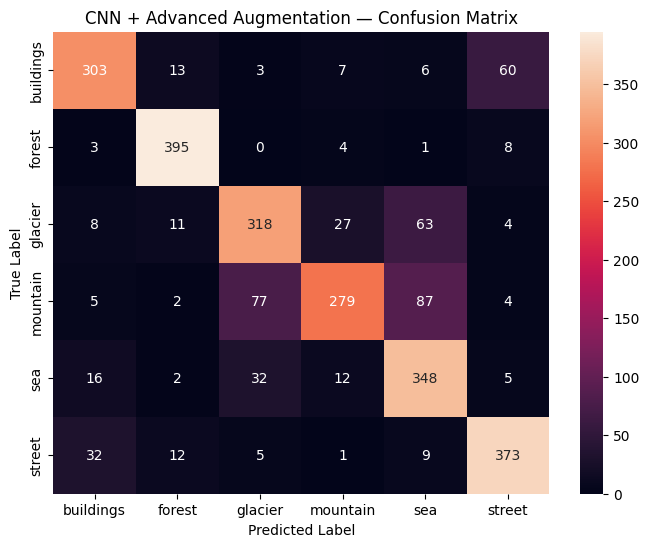

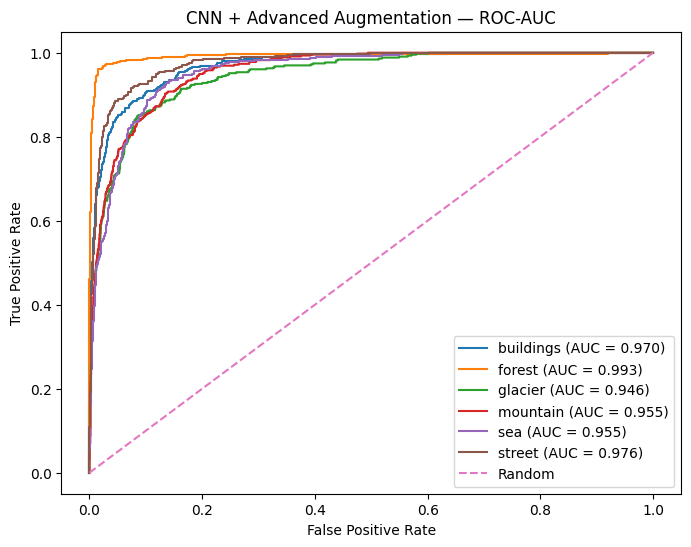

In [28]:
import numpy as np

advanced_test_loss, advanced_test_acc = advanced_model.evaluate(
    test_ds
)


y_true_advanced = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

y_pred_probs_advanced = advanced_model.predict(
    test_ds
)

y_pred_advanced = np.argmax(
    y_pred_probs_advanced,
    axis=1
)


advanced_waf1 = f1_score(
    y_true_advanced,
    y_pred_advanced,
    average="weighted"
)


advanced_cm = confusion_matrix(
    y_true_advanced,
    y_pred_advanced
)


y_true_advanced_bin = label_binarize(
    y_true_advanced,
    classes=np.arange(len(class_names))
)

advanced_roc_auc = roc_auc_score(
    y_true_advanced_bin,
    y_pred_probs_advanced,
    multi_class="ovr",
    average="weighted"
)


print("Test Loss:", advanced_test_loss)
print("Test Accuracy:", advanced_test_acc)
print("Weighted F1 Score:", advanced_waf1)
print("Weighted ROC-AUC:", advanced_roc_auc)
print("Training Time (seconds):", round(training_time, 2))

FIGURE_DIR = DRIVE_PROJECT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    advanced_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN + Advanced Augmentation — Confusion Matrix")

plt.savefig(
    FIGURE_DIR / "baseline_cnn_advanced_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_advanced_bin[:, i],
        y_pred_probs_advanced[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN + Advanced Augmentation — ROC-AUC")
plt.legend()

plt.savefig(
    FIGURE_DIR / "baseline_cnn_advanced_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Saving the Model

In [29]:
MODEL_DIR = DRIVE_PROJECT / "saved_models" / "cnn_advanced"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "baseline_cnn_advanced.keras"

advanced_model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/CSE475_Project/saved_models/cnn_advanced/baseline_cnn_advanced.keras


##### Saving Training History

In [30]:
HISTORY_DIR = DRIVE_PROJECT / "results" / "metrics"
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

history_path = HISTORY_DIR / "baseline_cnn_advanced_history.json"

with open(history_path, "w") as f:
    json.dump(advanced_history.history, f)

print("Training history saved to:", history_path)

Training history saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/baseline_cnn_advanced_history.json


##### Saving Evaluation Metrics

In [31]:
metrics_path = HISTORY_DIR / "baseline_cnn_advanced_metrics.json"

metrics = {
    "test_loss": float(advanced_test_loss),
    "test_accuracy": float(advanced_test_acc),
    "weighted_f1": float(advanced_waf1),
    "weighted_roc_auc": float(advanced_roc_auc),
    "training_time_seconds": float(training_time)
}

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Evaluation metrics saved to:", metrics_path)

Evaluation metrics saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/baseline_cnn_advanced_metrics.json
